# enrollment 길이와 무음 — `mode="min"` 절단이 무엇을 남기는가

wesep 의 TSE 학습은 등록 발화(enrollment)를 **배치 안에서 가장 짧은 것에 맞춰 잘라** 씁니다.
자르는 곳은 [`tse_collate_fn`](../wesep/dataset/dataset.py#L247-L253) 의 `mode="min"` 분기 하나뿐임.

자르는 방식이 `spk_embeds[i][:, :min_len, :]` — **앞에서부터 `min_len` 프레임만** 남김.
그래서 두 가지가 걱정됨:

| 걱정 | 물어야 할 것 |
|---|---|
| **길이** | 평균 11초짜리를 잘라 얼마나 남는가 |
| **무음** | 앞부분이 무음이면 화자 정보가 없는 구간만 남지 않는가 |

이 노트북이 하는 일:

| # | 하는 일 | 내는 것 |
|---|---|---|
| 1 | enrollment **원본 길이 분포** — wav 파일을 직접 읽어 | 통계표 + **히스토그램 · 누적분포** |
| 2 | `mode="min"` 이 배치에서 **얼마나 버리는가** — 배치 구성을 모의 | 통계표 + **원본/절단 겹친 히스토그램** |
| 3 | **발화 시작 전 무음** 길이 — 프레임 에너지로 | 통계표 + **앞뒤 무음 히스토그램** |
| 4 | 자른 뒤 남는 구간의 **발화 비율과 길이** | 통계표 + **히스토그램** |
| 5 | 정리 | 표 |

그래프 라벨은 **영문**임 — 이 환경에 설치된 폰트 19종이 전부 라틴 계열이라
한글을 쓰면 네모로 깨짐(실측).

| 항목 | 내용 |
|---|---|
| **커널** | **`wesep2`** — py3.9 · torch 2.7.1+cu128 |
| **읽는 것** | `data/clean/train-100/spk2enroll.json` 과 거기 적힌 wav 파일 |
| **건드리지 않는 것** | 저장소 코드·config·데이터. **읽기만 함.** 모델을 만들지 않고 GPU 를 쓰지 않음 |
| **모의하는 것** | 배치 구성만. 실제 `DataLoader` 를 돌리지 않고 길이 분포에서 표본을 뽑아 `min()` 을 계산 |

> 왜 모의인가 — 실제 `DataLoader` 를 한 에폭 돌리면 shard tar 를 전부 풀어야 해 수십 분이 걸림.
> 이 노트북이 보려는 것은 **길이 통계**뿐이고, 그것은 `spk2enroll.json` 의 wav 헤더만 읽어도 같은 값이 나옴.


In [1]:
import json
import random
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import display

%matplotlib inline
# 이 환경에 한글 폰트가 없어(폰트 19종 전부 라틴) 그래프 라벨은 영문으로 씀 - 안 그러면 네모로 깨짐
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.axisbelow": True, "font.size": 9})


def find_wesep_root(start: Path) -> Path:
    '''`wesep/__init__.py` 를 담고 있는 폴더를 위로 올라가며 찾음 - 그것이 wesep 클론 루트임.'''
    for d in (start, *start.parents):
        if (d / "wesep" / "__init__.py").is_file():
            return d
    raise FileNotFoundError(f"{start} 위쪽에 wesep 클론 루트가 없음")


WESEP  = find_wesep_root(Path.cwd())
RECIPE = WESEP / "examples/librimix/tse/v2"
ENROLL = RECIPE / "data/clean/train-100/spk2enroll.json"

# 재현을 위해 고정 - 저장소가 쓰는 seed 와 같은 값
SEED = 114514
random.seed(SEED)
np.random.seed(SEED)

# 학습 config 에서 그대로 가져온 값
BATCH_SIZE   = 8      # confs/bsrnn_ecapa_FiLM.yaml  dataloader_args.batch_size
NUM_SPEAKER  = 2      # Libri2Mix - tse_collate_fn 이 샘플 하나를 화자 수만큼 늘림
PER_BATCH    = BATCH_SIZE * NUM_SPEAKER          # collate 가 실제로 묶는 개수
FRAME_SHIFT  = 10     # ms.  confs/…yaml  dataset_args.fbank_args.frame_shift
SR           = 16000
HOP          = SR * FRAME_SHIFT // 1000          # 160 샘플 = 10 ms

N_UTT        = 300    # 파형까지 읽을 표본 수 (§3·§4 용)
N_HEADER     = 2000   # 헤더만 읽을 표본 수 (§1·§2 용 - 훨씬 빠름)
N_TRIAL      = 3000   # 배치 모의 횟수

pd.set_option("display.width", 200)

spk2enroll = json.loads(ENROLL.read_text())
paths = [p for _spk, lst in spk2enroll.items() for (_k, p) in lst]

setup = pd.DataFrame([
    {"항목": "wesep 루트",      "값": str(WESEP),                          "출처": "find_wesep_root(Path.cwd())"},
    {"항목": "enrollment 목록", "값": str(ENROLL.relative_to(WESEP)),      "출처": "run.sh stage 1 이 만듦"},
    {"항목": "화자 수",         "값": f"{len(spk2enroll):,}",              "출처": "spk2enroll.json 의 키 수"},
    {"항목": "발화 수",         "값": f"{len(paths):,}",                   "출처": "spk2enroll.json 의 값 전체"},
    {"항목": "batch_size",      "값": str(BATCH_SIZE),                     "출처": "confs/bsrnn_ecapa_FiLM.yaml dataloader_args"},
    {"항목": "화자 수/샘플",    "값": str(NUM_SPEAKER),                    "출처": "Libri2Mix"},
    {"항목": "collate 가 묶는 수", "값": f"{PER_BATCH}",                   "출처": "tse_collate_fn:218 이 화자 수만큼 늘림"},
    {"항목": "frame_shift",     "값": f"{FRAME_SHIFT} ms",                 "출처": "confs/…yaml dataset_args.fbank_args"},
    {"항목": "hop",             "값": f"{HOP} 샘플 @ {SR} Hz",             "출처": "SR * FRAME_SHIFT / 1000"},
    {"항목": "seed",            "값": str(SEED),                           "출처": "재현용 고정"},
])
display(setup)


# 초 <-> fbank 프레임 변환. frame_shift 10 ms 이므로 1 초 = 100 프레임.
FPS = 1000 / FRAME_SHIFT          # frames per second = 100


def add_sec_axis(ax, ticks_s):
    '''아래 x축이 fbank 프레임인 그림 위쪽에 초 축을 단다.

    보조축 눈금을 반드시 명시할 것 - 안 주면 matplotlib 이 알아서 고르는데
    250 프레임(2.5 초) 같은 값이 나와 아래 눈금과 안 맞는다.
    '''
    top = ax.secondary_xaxis("top", functions=(lambda fr: fr / FPS, lambda s: s * FPS))
    top.set_xticks(ticks_s)
    top.set_xlabel("duration (s)", fontsize=8)
    top.tick_params(labelsize=8)
    return top


# 아래 축은 fbank 프레임(모델이 실제로 받는 단위), 위 축은 사람이 읽는 초.
# 0~2000 프레임 = 0~20 초, 눈금은 200 프레임 = 2 초로 딱 떨어진다.
XLIM_FR  = (0, 1800)                           # enrollment 최댓값 1660 프레임(16.6 초)에 맞춤.
XTICK_FR = np.arange(0, 1801, 200)             # 0, 200, ..., 1800 프레임
XTICK_S  = np.arange(0, 19, 2)                 # 0, 2, ..., 18 초  (위 보조축)

# §3 무음은 최댓값이 61 프레임(0.61 초)뿐이라 위 범위를 쓰면 왼쪽 3 % 에 뭉개진다.
# 분포를 읽을 수 있게 따로 좁게 잡고, min_len 과의 대조는 별도 패널에서 한다.
XLIM_SIL_FR  = (0, 70)                         # 0~0.7 초
XTICK_SIL_FR = np.arange(0, 71, 10)            # 10 프레임 = 0.1 초
XTICK_SIL_S  = np.arange(0, 0.71, 0.1)


,항목,값,출처
0,wesep 루트,/workspace/git_clone/SD-FiLM/wesep,find_wesep_root(Path.cwd())
1,enrollment 목록,examples/librimix/tse/v2/data/clean/train-100/...,run.sh stage 1 이 만듦
2,화자 수,251,spk2enroll.json 의 키 수
3,발화 수,"27,800",spk2enroll.json 의 값 전체
4,batch_size,8,confs/bsrnn_ecapa_FiLM.yaml dataloader_args
5,화자 수/샘플,2,Libri2Mix
6,collate 가 묶는 수,16,tse_collate_fn:218 이 화자 수만큼 늘림
7,frame_shift,10 ms,confs/…yaml dataset_args.fbank_args
8,hop,160 샘플 @ 16000 Hz,SR * FRAME_SHIFT / 1000
9,seed,114514,재현용 고정


## 1. enrollment 원본 길이 분포

[`sample_enrollment`](../wesep/dataset/processor.py#L527) 이 `sf.read` 로 **wav 를 통째로** 읽음 — 자르지 않음.
[`random_chunk`](../wesep/dataset/processor.py#L697) 는 키에 `"wav"` 가 든 것만 자르는데 enrollment 의 키는 `embed_spk1` 이라 해당 없음.

그래서 여기서 보는 원본 길이가 곧 [`compute_fbank`](../wesep/dataset/processor.py#L565) 에 들어가는 길이임.

### 초 ↔ fbank 프레임

`frame_shift = 10 ms` 이므로 **1 초 = 100 프레임** 입니다.

| 초 | fbank 프레임 | 무엇 |
|---|---|---|
| 1 | 100 | 기준 |
| **3.0** | **300** | 관측된 **가장 짧은** enrollment |
| 11.2 | 1,117 | 평균 |
| 12.4 | 1,240 | 중앙값 |
| **16.6** | **1,660** | 관측된 **가장 긴** enrollment |

아래 그림은 **가로축(아래)을 `fbank 프레임`** 으로, **위쪽 보조축을 `초`** 로 답니다 —
프레임이 모델이 실제로 받는 단위이고, 초는 사람이 읽기 위한 것임.

범위는 **`0~2000프레임` = `0~20초`**, 눈금은 **200프레임 = 2초** 간격.
관측 최댓값 1,660프레임에 맞춘 `1700` 대신 `2000` 으로 잡은 이유는
두 축의 눈금이 **200 / 2 로 같이 떨어지기** 때문임.

> **보조축은 눈금을 반드시 명시해야 합니다** — 안 주면 matplotlib 이 알아서 고르는데
> `250프레임`(2.5초) 같은 값이 나와 아래 눈금과 어긋납니다(실측).


In [2]:
# 헤더만 읽어 길이를 구함 - 파형을 안 읽으므로 빠름
sample_hdr = random.sample(paths, N_HEADER)
secs = np.array([(lambda i: i.frames / i.samplerate)(sf.info(p)) for p in sample_hdr])
frames = np.round(secs * 1000 / FRAME_SHIFT).astype(int)

dist = pd.DataFrame({
    "초": pd.Series(secs).describe(percentiles=[.05, .25, .5, .75, .95]),
    "fbank 프레임": pd.Series(frames).describe(percentiles=[.05, .25, .5, .75, .95]),
}).round(2)
dist.loc["count"] = dist.loc["count"].astype(int)
display(dist)

display(pd.DataFrame([{
    "무엇을 쟀나": "wav 헤더의 frames / samplerate",
    "표본": f"{N_HEADER:,}개",
    "전체": f"{len(paths):,}개",
    "왜 헤더만": "파형을 안 읽어 빠름. 길이만 필요하므로 값이 같음",
}]))


,초,fbank 프레임
count,2000.00,2000.00
mean,11.17,1117.18
std,3.60,359.89
min,3.00,300.00
5%,3.96,395.85
25%,8.80,880.00
50%,12.40,1240.50
75%,14.02,1402.00
95%,15.34,1534.00
max,16.60,1660.00


,무엇을 쟀나,표본,전체,왜 헤더만
0,wav 헤더의 frames / samplerate,"2,000개","27,800개",파형을 안 읽어 빠름. 길이만 필요하므로 값이 같음


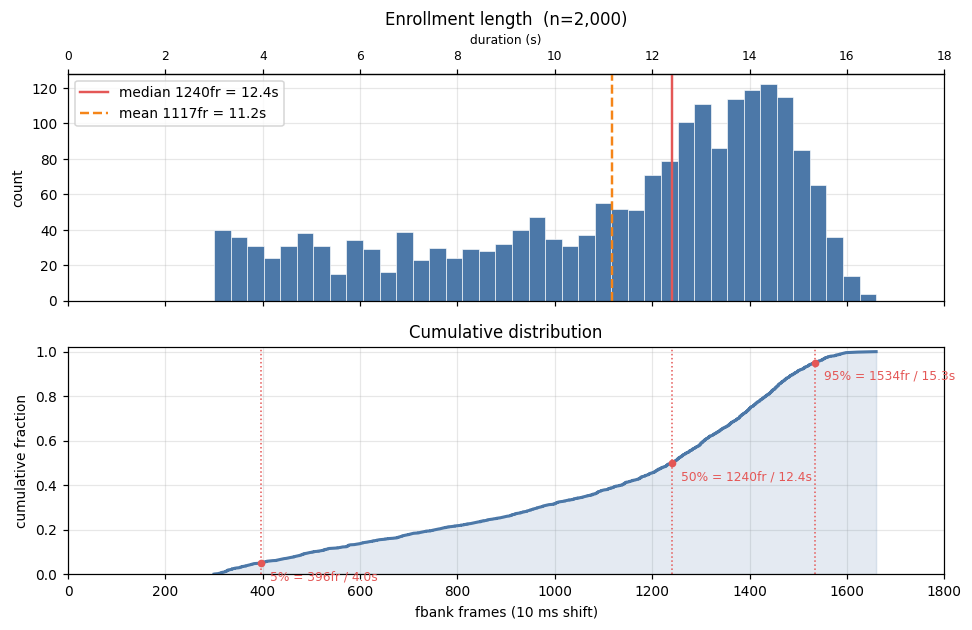

In [3]:
# 두 패널의 x 가 같은 "초" 이므로 세로로 쌓고 sharex 로 눈금을 묶는다 -
# 위아래로 놓으면 같은 x 값이 수직으로 정렬돼 분포와 누적을 함께 읽을 수 있다.
fig, ax = plt.subplots(2, 1, figsize=(9, 5.8), sharex=True)

ax[0].hist(frames, bins=40, color="#4C78A8", edgecolor="white", linewidth=0.4)
ax[0].axvline(np.median(frames), color="#E45756", lw=1.6,
              label=f"median {np.median(frames):.0f}fr = {np.median(secs):.1f}s")
ax[0].axvline(frames.mean(), color="#F58518", lw=1.6, ls="--",
              label=f"mean {frames.mean():.0f}fr = {secs.mean():.1f}s")
ax[0].set(ylabel="count", title=f"Enrollment length  (n={len(frames):,})",
          xlim=XLIM_FR, xticks=XTICK_FR)
ax[0].legend()
add_sec_axis(ax[0], XTICK_S)   # 초 축은 맨 위 패널에만 - 아래는 같은 x 를 공유함

# histtype="step" 은 edgecolor 로 선을 그림 - 여기에 "white" 를 주면 흰 배경에 흰 선이 되어 안 보인다.
# 왼쪽 막대 그래프의 edgecolor="white" 는 막대 사이 구분선이라 의도한 것이고, 여기와는 다르다.
xs = np.sort(frames)
ys = np.arange(1, len(xs) + 1) / len(xs)
ax[1].plot(xs, ys, color="#4C78A8", lw=2.0)
ax[1].fill_between(xs, ys, color="#4C78A8", alpha=0.15)
ax[1].set(xlabel="fbank frames (10 ms shift)", ylabel="cumulative fraction",
          title="Cumulative distribution", ylim=(0, 1.02))
for q in (0.05, 0.5, 0.95):
    v = np.quantile(frames, q)
    ax[1].axvline(v, color="#E45756", lw=1.0, ls=":")
    ax[1].plot([v], [q], "o", color="#E45756", ms=4)
    ax[1].annotate(f"{q:.0%} = {v:.0f}fr / {v/FPS:.1f}s", (v, q), textcoords="offset points",
                   xytext=(6, -11), fontsize=8, color="#E45756")

fig.tight_layout(); plt.show()


**분포가 좌우로 넓습니다** — 짧은 것이 3초대, 긴 것이 16초대로 **5배 차이**.
배치 하나에 이 분포에서 16개가 무작위로 뽑히므로, 최솟값은 **짧은 쪽 꼬리**에서 결정됨.

## 2. `mode="min"` 이 배치에서 얼마나 버리는가

[`tse_collate_fn`](../wesep/dataset/dataset.py#L206) 이 한 배치에서 하는 일:

| 줄 | 코드 | 내용 |
|---|---|---|
| [225](../wesep/dataset/dataset.py#L225) | `length_spk_embeds.append(spk_embeds[-1].shape[1])` | 16개의 `t_spk` 를 기록 |
| [229](../wesep/dataset/dataset.py#L229) | `if not (len(set(length_spk_embeds)) == 1):` | 전부 같으면 통과 |
| [248](../wesep/dataset/dataset.py#L248) | `min_len = min(length_spk_embeds)` | **가장 짧은 것** |
| [253](../wesep/dataset/dataset.py#L253) | `spk_embeds[i] = spk_embeds[i][:, :min_len, :]` | **앞에서부터** `min_len` 만 남김 |

배치마다 뽑히는 16개가 다르므로 `min_len` 도 배치마다 달라짐.


In [4]:
rng = np.random.default_rng(SEED)
min_lens, kept_ratio = [], []
for _ in range(N_TRIAL):
    b = rng.choice(frames, size=PER_BATCH, replace=False)
    m = int(b.min())
    min_lens.append(m)
    kept_ratio.append(m * len(b) / b.sum())      # 남는 프레임 / 원래 프레임

min_lens = np.array(min_lens)
kept_ratio = np.array(kept_ratio)

trunc = pd.DataFrame({
    "min_len (프레임)": pd.Series(min_lens).describe(percentiles=[.05, .5, .95]),
    "min_len (초)": pd.Series(min_lens / 100).describe(percentiles=[.05, .5, .95]),
    "남는 비율": pd.Series(kept_ratio).describe(percentiles=[.05, .5, .95]),
}).round(3)
trunc.loc["count"] = trunc.loc["count"].astype(int)
display(trunc)

n_batch_per_epoch = 13900 // BATCH_SIZE
ep = rng.choice(frames, size=(n_batch_per_epoch, PER_BATCH), replace=True).min(axis=1)
summary = pd.DataFrame([{
    "배치 모의 횟수": N_TRIAL,
    "버려지는 비율 평균": f"{(1 - kept_ratio.mean()) * 100:.1f}%",
    "한 에폭 배치 수(근사)": n_batch_per_epoch,
    "한 에폭의 서로 다른 min_len": len(np.unique(ep)),
}])
display(summary)


,min_len (프레임),min_len (초),남는 비율
count,3000.000,3000.000,3000.000
mean,421.476,4.215,0.376
std,123.898,1.239,0.093
min,300.000,3.000,0.240
5%,310.000,3.100,0.276
50%,378.000,3.780,0.349
95%,684.050,6.840,0.568
max,1178.000,11.780,0.891


,배치 모의 횟수,버려지는 비율 평균,한 에폭 배치 수(근사),한 에폭의 서로 다른 min_len
0,3000,62.4%,1737,258


/tmp/ipykernel_1125483/4004579609.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


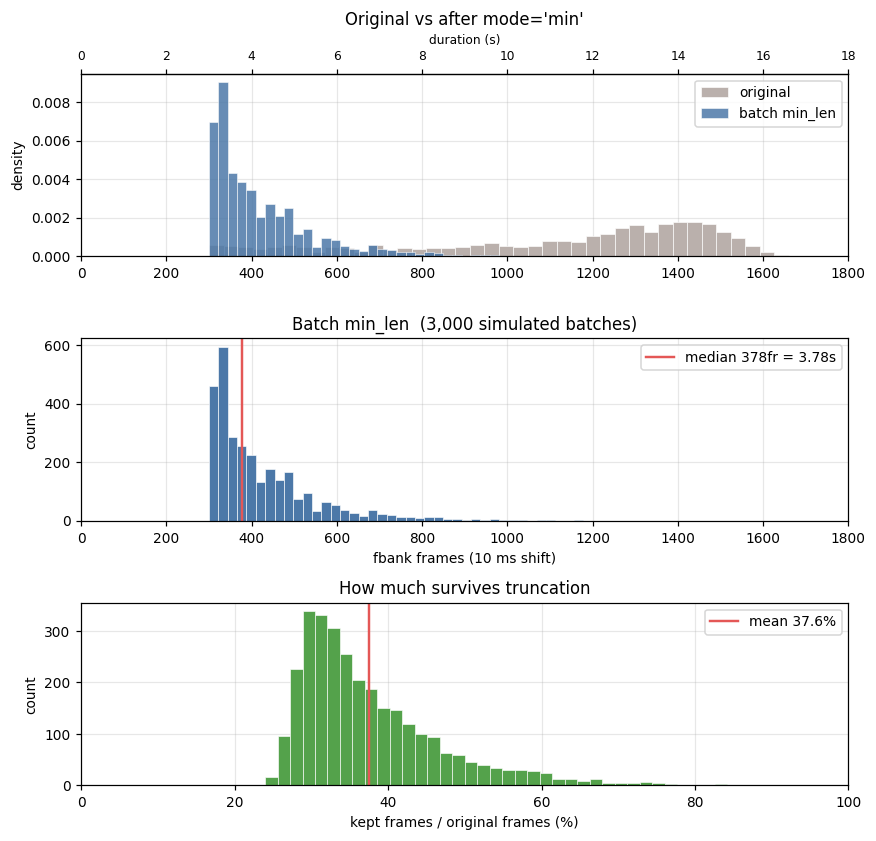

In [5]:
# 위 두 패널은 x 가 "초" 로 같아 sharex 로 묶고, 맨 아래 % 패널만 따로 둔다.
# gridspec 을 쓰는 이유 - plt.subplots(sharex=True) 는 셋 다 묶어 버린다.
fig = plt.figure(figsize=(9, 8.4))
gs = fig.add_gridspec(3, 1, hspace=0.45)
ax = [fig.add_subplot(gs[0])]
ax.append(fig.add_subplot(gs[1], sharex=ax[0]))
ax.append(fig.add_subplot(gs[2]))

ax[0].hist(frames, bins=40, color="#BAB0AC", edgecolor="white", linewidth=0.4,
           density=True, label="original")
ax[0].hist(min_lens, bins=40, color="#4C78A8", edgecolor="white", linewidth=0.4,
           density=True, alpha=0.85, label="batch min_len")
ax[0].set(ylabel="density", title="Original vs after mode='min'",
          xlim=XLIM_FR, xticks=XTICK_FR)
ax[0].legend()
add_sec_axis(ax[0], XTICK_S)   # 초 축은 맨 위 패널에만

ax[1].hist(min_lens, bins=40, color="#4C78A8", edgecolor="white", linewidth=0.4)
ax[1].axvline(np.median(min_lens), color="#E45756", lw=1.6,
              label=f"median {np.median(min_lens):.0f}fr = {np.median(min_lens)/FPS:.2f}s")
ax[1].set(xlabel="fbank frames (10 ms shift)", ylabel="count",
          title=f"Batch min_len  ({N_TRIAL:,} simulated batches)")
ax[1].legend()

ax[2].hist(kept_ratio * 100, bins=40, color="#54A24B", edgecolor="white", linewidth=0.4)
ax[2].axvline(kept_ratio.mean() * 100, color="#E45756", lw=1.6,
              label=f"mean {kept_ratio.mean()*100:.1f}%")
ax[2].set(xlabel="kept frames / original frames (%)", ylabel="count",
          title="How much survives truncation", xlim=(0, 100),
          xticks=np.arange(0, 101, 20))
ax[2].legend()

fig.tight_layout(); plt.show()


**`Original vs after mode='min'` 패널이 이 절의 요점입니다** —
회색(`original`)이 300~1,660프레임(3~16.6초)에 퍼져 있는데
파랑(`batch min_len`)은 **짧은 쪽에 몰려 있음.**
16개 중 최솟값을 고르니 분포의 **짧은 쪽 꼬리만** 남는 것임.

## 3. 발화 앞뒤의 무음 길이

### 이 절이 답하는 질문

[`tse_collate_fn`](../wesep/dataset/dataset.py#L253) 의 `spk_embeds[i][:, :min_len, :]` 는
**앞에서부터** `min_len` 프레임만 남깁니다. 그래서 이런 걱정이 생김:

> 어떤 발화가 **앞부분이 죄다 무음**이면, 잘라낸 뒤 **목소리가 없는 구간만** 남는 것 아닌가?

그러면 화자 인코더가 아무 정보도 못 받아 학습이 망가짐. 실제로 그런 일이 생기는지 재는 절임.

### 용어 — `leading` · `trailing`

enrollment wav 하나를 펼치면 이렇게 생겼습니다:

```
원본 enrollment wav        (예: 12.4 초 = 1,240 프레임)

  |<- leading ->|<------------ 목소리 구간 ------------>|<- trailing ->|
  |    무음     |                                       |     무음     |
  0           0.1 초                                  12.0 초       12.4 초

  [:min_len] 이 남기는 것   (min_len = 3.0 초 = 300 프레임인 배치라면)
  |<--------- 300 프레임 --------->|
          ^^^^^^^^^^^^^^^^^^^^^^^^  <- 이 안에 목소리가 얼마나 들어 있나?
```

| 용어 | 뜻 | 왜 보는가 |
|---|---|---|
| **`leading` 무음** | 파일 **맨 앞**부터 첫 목소리가 나올 때까지 | `[:min_len]` 이 **앞**을 남기므로 **이것이 직접 위협** |
| **`trailing` 무음** | 마지막 목소리 뒤부터 파일 **끝**까지 | 잘라내면 어차피 사라지는 쪽. **비교용**으로 같이 잼 |
| **`voiced ratio`** | 발화 하나에서 목소리 프레임이 차지하는 비율 | 파일 전체가 얼마나 알찬지 |

### 목소리가 있는지 없는지를 어떻게 판정했나

**`silero-vad` 를 쓰지 않았습니다.** 10 ms 프레임마다 **평균 제곱 에너지**를 구해,
**그 발화 자신의 최대 프레임 에너지의 `1e-4`(= −40 dB)** 를 넘으면 `목소리`, 아니면 `무음` 으로 봤음.

| 항목 | 선택 | 왜 |
|---|---|---|
| 판정 방법 | **프레임 에너지 임계** | 학습 파이프라인에도 VAD 가 **안 걸려 있음** — [`dataset/vad.py`](../wesep/dataset/vad.py) 는 어디서도 import 안 되고, `silero-vad` 는 [`cli/extractor.py`](../wesep/cli/extractor.py#L34) 의 **추론 CLI 전용**임. 학습이 보는 것과 같은 조건으로 재려면 VAD 없이 봐야 함 |
| 임계 | **상대값** (최댓값의 −40 dB) | 절대값이면 녹음 레벨이 낮은 발화가 통째로 `무음` 으로 잡힘 |
| 프레임 | 10 ms | [`compute_fbank`](../wesep/dataset/processor.py#L565) 의 `frame_shift` 와 같게 |

> 이 판정은 **거친 근사**임. 숨소리·잡음을 `목소리` 로 셀 수 있고, 아주 작은 발성을 `무음` 으로 놓칠 수 있음.
> 여기서 알고 싶은 것은 *"무음이 `min_len` 만큼 길어질 수 있는가"* 이고,
> 그 판정에는 **자릿수만 맞으면** 충분하므로 이 방법을 씀.


In [6]:
def frame_energy(x: np.ndarray) -> np.ndarray:
    '''10 ms 프레임마다 평균 제곱 에너지.'''
    n = len(x) // HOP
    return (x[:n * HOP].reshape(n, HOP) ** 2).mean(axis=1)


REL_THRESHOLD = 1e-4          # 최대 프레임 에너지 대비 -40 dB

sample_wav = random.sample(paths, N_UTT)
utts = []
for p in sample_wav:
    x, sr = sf.read(p, dtype="float32")
    assert sr == SR, f"{p} 의 sr 이 {sr}"
    e = frame_energy(x)
    voiced = e > e.max() * REL_THRESHOLD
    utts.append({
        "n_frames": len(e),
        "voiced": voiced,
        "lead_sil": int(np.argmax(voiced)) if voiced.any() else len(e),
        "tail_sil": int(np.argmax(voiced[::-1])) if voiced.any() else len(e),
        "voiced_ratio": float(voiced.mean()),
    })

sil = pd.DataFrame({
    "앞 무음 (프레임)": pd.Series([u["lead_sil"] for u in utts]),
    "앞 무음 (초)": pd.Series([u["lead_sil"] / 100 for u in utts]),
    "뒤 무음 (초)": pd.Series([u["tail_sil"] / 100 for u in utts]),
    "발화 프레임 비율": pd.Series([u["voiced_ratio"] for u in utts]),
}).describe(percentiles=[.5, .95, .99]).round(3)
sil.loc["count"] = sil.loc["count"].astype(int)
display(sil)

display(pd.DataFrame([{
    "무엇을 쟀나": "10 ms 프레임마다 평균 제곱 에너지",
    "표본": f"{N_UTT}개 (파형까지 읽음)",
    "발화/무음 임계": f"발화별 최대 프레임 에너지의 {REL_THRESHOLD:g} (= -40 dB)",
    "왜 상대 임계": "절대값이면 녹음 레벨 차이에 휘둘림",
}]))

# 히스토그램의 모양을 숫자로도 남긴다 - 그림만 보면 "어디에 몰려 있나" 를 말로 못 옮긴다
_lead = np.array([u["lead_sil"] for u in utts])
_tail = np.array([u["tail_sil"] for u in utts])
BUCKETS = [(0, 0, "0 (무음 없음)"), (1, 5, "1~5"), (6, 20, "6~20"),
           (21, 40, "21~40"), (41, 10**9, "41 이상")]
bucket = pd.DataFrame([
    {"무음 길이 (프레임)": name,
     "초": f"{lo/FPS:.2f}~{hi/FPS:.2f}" if hi < 10**9 else f"{lo/FPS:.2f}~",
     "leading 건수": int(((_lead >= lo) & (_lead <= hi)).sum()),
     "leading 비율": f"{((_lead >= lo) & (_lead <= hi)).mean()*100:.1f}%",
     "trailing 건수": int(((_tail >= lo) & (_tail <= hi)).sum()),
     "trailing 비율": f"{((_tail >= lo) & (_tail <= hi)).mean()*100:.1f}%"}
    for lo, hi, name in BUCKETS])
display(bucket)

display(pd.DataFrame([
    {"무음": "leading",
     "최빈값": f"{np.bincount(_lead).argmax()}fr ({np.bincount(_lead).max()}건)",
     "중앙값": f"{np.median(_lead):.0f}fr", "최대": f"{_lead.max()}fr = {_lead.max()/FPS:.2f}s"},
    {"무음": "trailing",
     "최빈값": f"{np.bincount(_tail).argmax()}fr ({np.bincount(_tail).max()}건)",
     "중앙값": f"{np.median(_tail):.0f}fr", "최대": f"{_tail.max()}fr = {_tail.max()/FPS:.2f}s"},
]))


,앞 무음 (프레임),앞 무음 (초),뒤 무음 (초),발화 프레임 비율
count,300.000,300.00,300.000,300.000
mean,15.023,0.15,0.070,0.840
std,17.999,0.18,0.131,0.111
min,0.000,0.00,0.000,0.431
50%,7.000,0.07,0.000,0.836
95%,55.000,0.55,0.391,1.000
99%,58.000,0.58,0.510,1.000
max,61.000,0.61,0.560,1.000


,무엇을 쟀나,표본,발화/무음 임계,왜 상대 임계
0,10 ms 프레임마다 평균 제곱 에너지,300개 (파형까지 읽음),발화별 최대 프레임 에너지의 0.0001 (= -40 dB),절대값이면 녹음 레벨 차이에 휘둘림


,무음 길이 (프레임),초,leading 건수,leading 비율,trailing 건수,trailing 비율
0,0 (무음 없음),0.00~0.00,112,37.3%,199,66.3%
1,1~5,0.01~0.05,33,11.0%,14,4.7%
2,6~20,0.06~0.20,62,20.7%,42,14.0%
3,21~40,0.21~0.40,56,18.7%,32,10.7%
4,41 이상,0.41~,37,12.3%,13,4.3%


,무음,최빈값,중앙값,최대
0,leading,0fr (112건),7fr,61fr = 0.61s
1,trailing,0fr (199건),0fr,56fr = 0.56s


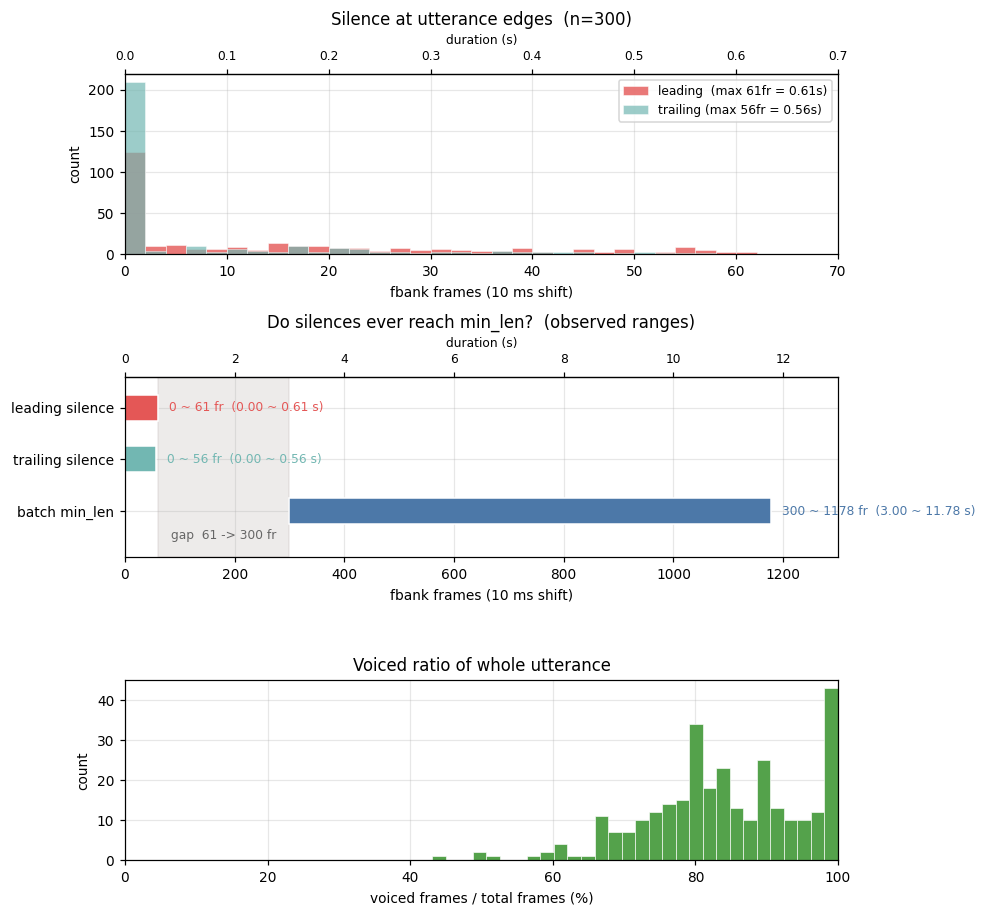

In [7]:
lead = np.array([u["lead_sil"] for u in utts])
tail = np.array([u["tail_sil"] for u in utts])

# 세 패널의 x 단위가 모두 달라 sharex 없이 세로로만 쌓는다.
fig, ax = plt.subplots(3, 1, figsize=(9, 8.4))

# --- 1) 무음 분포. 최댓값이 61 프레임이라 축을 0~70 으로 좁혀야 모양이 보인다 ---
ax[0].hist(lead, bins=np.arange(0, 71, 2), color="#E45756", edgecolor="white",
           linewidth=0.4, alpha=0.8,
           label=f"leading  (max {lead.max():.0f}fr = {lead.max()/FPS:.2f}s)")
ax[0].hist(tail, bins=np.arange(0, 71, 2), color="#72B7B2", edgecolor="white",
           linewidth=0.4, alpha=0.7,
           label=f"trailing (max {tail.max():.0f}fr = {tail.max()/FPS:.2f}s)")
ax[0].set(xlabel="fbank frames (10 ms shift)", ylabel="count",
          title=f"Silence at utterance edges  (n={len(utts)})",
          xlim=XLIM_SIL_FR, xticks=XTICK_SIL_FR)
ax[0].legend(fontsize=8)
add_sec_axis(ax[0], XTICK_SIL_S)

# --- 2) 무음과 min_len 이 겹치는 구간이 있는지 - 가로 막대로 범위만 비교 ---
bars = [("leading silence",  lead.min(),      lead.max(),      "#E45756"),
        ("trailing silence", tail.min(),      tail.max(),      "#72B7B2"),
        ("batch min_len",    min_lens.min(),  min_lens.max(),  "#4C78A8")]
for i, (name, lo, hi, c) in enumerate(bars):
    ax[1].barh(i, hi - lo, left=lo, height=0.5, color=c, edgecolor="white")
    ax[1].text(hi + 20, i, f"{lo:.0f} ~ {hi:.0f} fr  ({lo/FPS:.2f} ~ {hi/FPS:.2f} s)",
               va="center", fontsize=8, color=c)
ax[1].axvspan(lead.max(), min_lens.min(), color="#BAB0AC", alpha=0.25, zorder=0)
ax[1].text((lead.max() + min_lens.min()) / 2, 2.55,
           f"gap  {lead.max():.0f} -> {min_lens.min():.0f} fr", ha="center",
           fontsize=8, color="#666")
ax[1].set(yticks=range(len(bars)), yticklabels=[b[0] for b in bars],
          xlabel="fbank frames (10 ms shift)", xlim=(0, 1300),
          xticks=np.arange(0, 1301, 200), ylim=(-0.6, 2.9),
          title="Do silences ever reach min_len?  (observed ranges)")
ax[1].invert_yaxis()
add_sec_axis(ax[1], np.arange(0, 13, 2))

# --- 3) 발화 전체에서 발화 프레임이 차지하는 비율 ---
ax[2].hist([u["voiced_ratio"] * 100 for u in utts], bins=30,
           color="#54A24B", edgecolor="white", linewidth=0.4)
ax[2].set(xlabel="voiced frames / total frames (%)", ylabel="count",
          title="Voiced ratio of whole utterance",
          xlim=(0, 100), xticks=np.arange(0, 101, 20))

fig.tight_layout(); plt.show()


### `Silence at utterance edges` 가 말하는 것

**가장 큰 막대가 `0프레임` 입니다** — 파일이 시작하자마자 목소리가 나오는 발화가 그만큼 많다는 뜻.

아래 수치는 이 절의 코드 셀이 출력한 구간별 표와 같은 값임 (표본 300개, `SEED = 114514`).

| 무음 길이 | `leading` (빨강) | `trailing` (청록) |
|---|---|---|
| **0프레임** (무음 없음) | **112건 (37.3%)** | **199건 (66.3%)** |
| 1~5프레임 (0.01~0.05초) | 33건 (11.0%) | 14건 (4.7%) |
| 6~20프레임 (0.06~0.20초) | 62건 (20.7%) | 42건 (14.0%) |
| 21~40프레임 (0.21~0.40초) | 56건 (18.7%) | 32건 (10.7%) |
| 41프레임 이상 (0.41초~) | 37건 (12.3%) | 13건 (4.3%) |
| **최빈값** | **0프레임** | **0프레임** |
| 중앙값 | 7프레임 (0.07초) | **0프레임** |
| 최대 | **61프레임 (0.61초)** | 56프레임 (0.56초) |

읽히는 것 세 가지:

| # | 무엇이 보이나 | 왜 그런가 |
|---|---|---|
| 1 | **`0프레임` 막대가 압도적으로 큼** | LibriSpeech 발화는 이미 **말이 시작·끝나는 지점에서 잘려** 있음. 앞뒤에 긴 공백을 두지 않음 |
| 2 | **`trailing`(66.3%) 이 `leading`(37.3%) 보다 `0` 에 더 몰림** | 분절이 **말이 끝나는 곳**을 기준으로 잘려서, 뒤쪽이 더 깔끔함 |
| 3 | 꼬리가 **61프레임(0.61초)에서 끊김** | 그보다 긴 앞 무음을 가진 발화가 **300개 표본에 하나도 없음** |

3번이 이 절의 결론으로 이어집니다 — 가장 긴 무음이 **0.61초**인데 가장 짧은 `min_len` 이 **3.0초**라,
`[:min_len]` 이 남기는 구간에 **목소리가 반드시 들어감.**

### `Do silences ever reach min_len?` 가 말하는 것

**히스토그램이 아니라 `범위 막대`** 입니다. 막대 하나가 그 값의 **최솟값에서 최댓값까지**를 잇는 선임.

```
                0        300      600      900     1200   (fbank frames)
                |---------|--------|--------|--------|
leading  silence ▬▬                                       0 ~ 61
trailing silence ▬▬                                       0 ~ 56
                   ░░░░░░░  <- 회색 띠 = 겹치지 않는 간격 (61 ~ 300)
batch min_len            ▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬             300 ~ 1,178
```

| 그림의 요소 | 뜻 |
|---|---|
| 막대의 **왼쪽 끝** | 그 값의 **최솟값** |
| 막대의 **오른쪽 끝** | 그 값의 **최댓값** |
| 막대 옆 글자 | `최솟값 ~ 최댓값 fr (초 ~ 초)` |
| **회색 띠** | 무음의 최댓값(61)과 `min_len` 의 최솟값(300) **사이의 빈 구간** |

### 이 그림이 답하는 질문

> `[:min_len]` 이 남기는 구간이 **통째로 무음**이 되려면,
> 그 발화의 앞 무음이 **`min_len` 보다 길어야** 합니다. 그런 일이 가능한가?

가능하려면 **`leading silence` 막대와 `batch min_len` 막대가 겹쳐야** 합니다 —
어떤 발화의 무음 길이가 어떤 배치의 `min_len` 이상이 되는 조합이 있어야 하니까.

| 값 | 범위 | 의미 |
|---|---|---|
| `leading silence` 의 **최댓값** | **61프레임 (0.61초)** | 가장 나쁜 발화도 이 정도만 무음 |
| `batch min_len` 의 **최솟값** | **300프레임 (3.0초)** | 가장 짧게 잘리는 배치도 이만큼은 남김 |
| 둘 사이 | **239프레임 (2.4초)** | **겹치는 구간이 없음** |

**막대가 안 겹치므로 답은 "불가능" 입니다.** 가장 나쁜 조합을 가정해도
(가장 무음이 긴 발화 × 가장 짧게 자르는 배치) `61 < 300` 이라
남는 구간에 **최소 239프레임(2.4초)의 목소리**가 들어감.

### 왜 히스토그램이 아니라 범위로 그렸나

이 질문은 **분포의 모양이 아니라 양 끝**에 달려 있기 때문임 —
*"가장 무음이 긴 발화"* 와 *"가장 짧게 자르는 배치"* 만 비교하면 답이 나옵니다.
히스토그램으로 그리면 무음(0~61)이 축 왼쪽 5%에 뭉개져 오히려 안 보임.

### 어떻게 읽나

| 패널 | 무엇을 보는가 | 읽는 법 |
|---|---|---|
| `Silence at utterance edges` | **빨강** = `leading`(파일 맨 앞의 무음)<br>**청록** = `trailing`(파일 맨 뒤의 무음) | 가로축이 **0~70프레임(0~0.7초)** 임 — 무음이 그만큼 짧아서 이 범위로 좁혀야 모양이 보임.<br>둘 다 **0 근처에 몰려** 있고, 가장 긴 것이 **61프레임(0.61초)** |
| `Do silences ever reach min_len?` | 무음 범위와 `min_len` 범위가 **겹치는지** | 막대는 **최솟값~최댓값**을 잇는 선임(히스토그램 아님).<br>빨강·청록이 **왼쪽 끝에 붙어** 있고 파랑은 **한참 오른쪽** — 안 겹침.<br>회색 띠가 그 **간격(61 → 300프레임)** |
| `Voiced ratio of whole utterance` | 발화 하나에서 발화 프레임이 차지하는 비율 | 대부분 **80% 이상** |

### 왜 무음이 문제가 안 되나

`Do silences ever reach min_len?` 패널이 요점입니다.

| 구간 | 범위 |
|---|---|
| 앞 무음 | **0 ~ 61프레임** (0 ~ 0.61초) |
| 뒤 무음 | 0 ~ 56프레임 (0 ~ 0.56초) |
| **배치 `min_len`** | **300 ~ 1,178프레임** (3.0 ~ 11.8초) |

**두 범위가 겹치지 않습니다** — 가장 긴 무음(61)과 가장 짧은 `min_len`(300) 사이에 **239프레임(2.4초)의 간격**이 있음.
`[:min_len]` 이 아무리 나쁘게 잘라도 **무음만 남을 수 없는** 이유임.

## 4. 자른 뒤 남는 구간에 목소리가 얼마나 있나

§3 은 **원본 발화**의 무음을 봤고, 이 절은 **실제로 잘라낸 뒤** 무엇이 남는지 봅니다.

절차:

| # | 하는 일 |
|---|---|
| 1 | §3 에서 파형까지 읽은 **300개**에서 16개를 무작위로 뽑아 배치 하나를 만듦 |
| 2 | 그 16개의 **최솟값**을 `min_len` 으로 삼음 — [`tse_collate_fn`](../wesep/dataset/dataset.py#L248) 과 같은 규칙 |
| 3 | 16개를 전부 `voiced[:min_len]` 으로 자름 — [`:253`](../wesep/dataset/dataset.py#L253) 과 같은 방식 |
| 4 | **남은 구간에** §3 과 **같은 에너지 판정**을 다시 적용해 목소리 프레임을 셈 |
| 5 | 1~4 를 3,000번 반복 → 16 × 3,000 = **48,000건** |

재는 것 두 가지:

| 측정 항목 | 뜻 | 나쁘면 무슨 뜻인가 |
|---|---|---|
| **발화 비율** | `자른 구간의 목소리 프레임 / min_len` | 0 에 가까우면 **무음만 남았다**는 뜻 |
| **발화 길이** | `자른 구간의 목소리 프레임` (초로 환산) | 짧으면 화자 정보가 적다는 뜻 |


In [8]:
nfr = np.array([u["n_frames"] for u in utts])
rows = []
for _ in range(N_TRIAL):
    idx = rng.choice(len(utts), size=PER_BATCH, replace=False)
    m = int(nfr[idx].min())
    for i in idx:
        v = utts[i]["voiced"][:m]
        rows.append({"min_len": m, "발화 프레임": int(v.sum()), "발화 비율": float(v.mean())})

after = pd.DataFrame(rows)
stat = pd.DataFrame({
    "발화 비율": after["발화 비율"],
    "발화 길이 (초)": after["발화 프레임"] / 100,
}).describe(percentiles=[.001, .01, .05, .5, .95]).round(3)
stat.loc["count"] = stat.loc["count"].astype(int)
display(stat)

thr = pd.DataFrame([
    {"발화 비율 기준": f"{t * 100:.0f}% 미만",
     "해당 샘플 수": int((after["발화 비율"] < t).sum()),
     "비율": f"{(after['발화 비율'] < t).mean() * 100:.3f}%"}
    for t in (0.05, 0.10, 0.20, 0.30, 0.50)
])
display(thr)


,발화 비율,발화 길이 (초)
count,48000.000,48000.000
mean,0.836,3.757
std,0.129,1.348
min,0.286,0.890
0.1%,0.329,1.110
1%,0.443,1.750
5%,0.601,2.170
50%,0.856,3.360
95%,1.000,6.410
max,1.000,11.450


,발화 비율 기준,해당 샘플 수,비율
0,5% 미만,0,0.000%
1,10% 미만,0,0.000%
2,20% 미만,0,0.000%
3,30% 미만,21,0.044%
4,50% 미만,823,1.715%


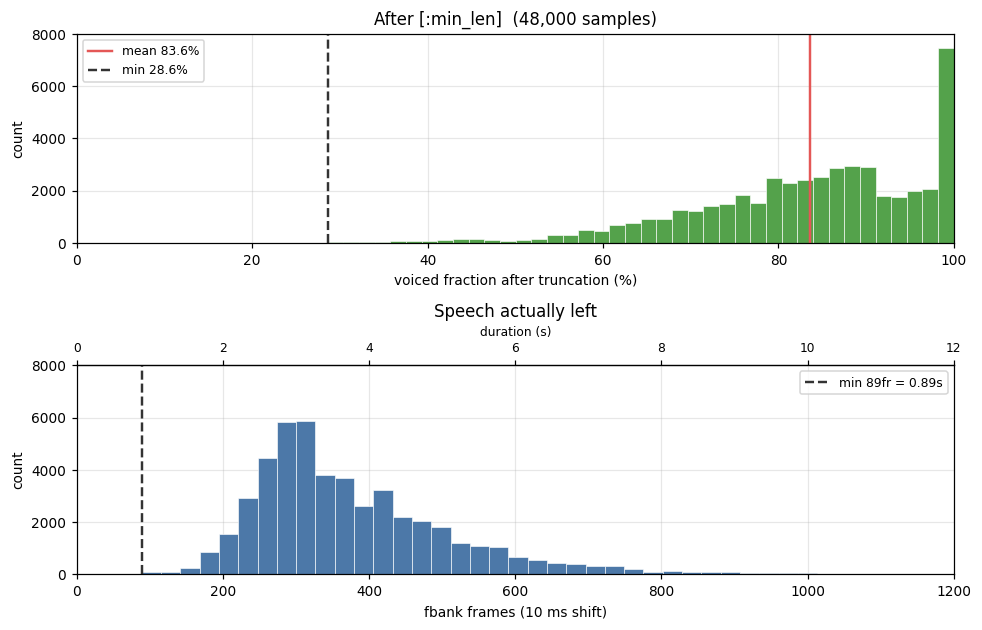

In [9]:
# 위는 "%", 아래는 "초" 로 단위가 달라 sharex 를 쓰지 않는다. 세로로만 쌓음.
fig, ax = plt.subplots(2, 1, figsize=(9, 5.8))

ax[0].hist(after["발화 비율"] * 100, bins=40, color="#54A24B",
           edgecolor="white", linewidth=0.4)
ax[0].axvline(after["발화 비율"].mean() * 100, color="#E45756", lw=1.6,
              label=f"mean {after['발화 비율'].mean()*100:.1f}%")
ax[0].axvline(after["발화 비율"].min() * 100, color="#333", lw=1.6, ls="--",
              label=f"min {after['발화 비율'].min()*100:.1f}%")
# 두 행이 같은 48,000건의 count 이므로 y 도 맞춰야 높이가 비교된다
YLIM_CNT, YTICK_CNT = (0, 8000), np.arange(0, 8001, 2000)

ax[0].set(xlabel="voiced fraction after truncation (%)", ylabel="count",
          title=f"After [:min_len]  ({len(after):,} samples)",
          xlim=(0, 100), xticks=np.arange(0, 101, 20),
          ylim=YLIM_CNT, yticks=YTICK_CNT)
ax[0].legend(fontsize=8)

ax[1].hist(after["발화 프레임"], bins=40, color="#4C78A8",
           edgecolor="white", linewidth=0.4)
ax[1].axvline(after["발화 프레임"].min(), color="#333", lw=1.6, ls="--",
              label=f"min {after['발화 프레임'].min():.0f}fr = {after['발화 프레임'].min()/FPS:.2f}s")
# 자른 뒤 남는 발화는 최댓값이 1,145 프레임이라 XLIM_FR(1800)을 쓰면 오른쪽 36 % 가 빈다.
# 여기는 원본 분포와 겹쳐 보는 패널이 아니므로 데이터에 맞춰 좁힌다.
ax[1].set(xlabel="fbank frames (10 ms shift)", ylabel="count",
          title="Speech actually left", xlim=(0, 1200),
          xticks=np.arange(0, 1201, 200), ylim=YLIM_CNT, yticks=YTICK_CNT)
add_sec_axis(ax[1], np.arange(0, 13, 2))
ax[1].legend(fontsize=8)

fig.tight_layout(); plt.show()


`After [:min_len]` 패널이 **0% 근처에 아무것도 없음** — 이것이 *"무음만 남지 않나"* 에 대한 답임.
가장 나쁜 경우에도 `Speech actually left` 패널의 **검은 파선**만큼(89프레임 = 0.89초)은 발화가 남음.

두 패널의 세로축을 **같은 `0~8,000`** 으로 맞췄으므로 막대 높이를 그대로 견줄 수 있음 —
둘 다 같은 48,000건을 센 것임.

## 5. 정리


In [10]:
final = pd.DataFrame([
    {"항목": "enrollment 원본 길이", "값": f"{secs.min():.1f} ~ {secs.max():.1f} 초 (중앙값 {np.median(secs):.1f})",
     "판정": "제각각"},
    {"항목": "배치의 min_len", "값": f"{min_lens.min()/100:.1f} ~ {min_lens.max()/100:.1f} 초 (중앙값 {np.median(min_lens)/100:.1f})",
     "판정": "배치마다 다름"},
    {"항목": "한 에폭의 서로 다른 min_len", "값": f"{len(np.unique(ep))} 개",
     "판정": "torch.compile 이 dynamic 축으로 처리"},
    {"항목": "버려지는 오디오", "값": f"평균 {(1 - kept_ratio.mean()) * 100:.1f}%",
     "판정": "손실이 큼"},
    {"항목": "발화 시작 전 무음", "값": f"중앙값 {np.median([u['lead_sil'] for u in utts])/100:.2f} 초 · 최대 {max(u['lead_sil'] for u in utts)/100:.2f} 초",
     "판정": "짧음"},
    {"항목": "자른 뒤 발화 비율", "값": f"평균 {after['발화 비율'].mean()*100:.1f}% · 최소 {after['발화 비율'].min()*100:.1f}%",
     "판정": f"20% 미만 {int((after['발화 비율']<0.2).sum())}건 - 무음만 남는 경우 없음"},
    {"항목": "자른 뒤 발화 길이", "값": f"중앙값 {after['발화 프레임'].median()/100:.2f} 초 · 최소 {after['발화 프레임'].min()/100:.2f} 초",
     "판정": f"1%tile 이 {after['발화 프레임'].quantile(.01)/100:.2f} 초 - 꼬리는 짧음"},
])
display(final)


,항목,값,판정
0,enrollment 원본 길이,3.0 ~ 16.6 초 (중앙값 12.4),제각각
1,배치의 min_len,3.0 ~ 11.8 초 (중앙값 3.8),배치마다 다름
2,한 에폭의 서로 다른 min_len,258 개,torch.compile 이 dynamic 축으로 처리
3,버려지는 오디오,평균 62.4%,손실이 큼
4,발화 시작 전 무음,중앙값 0.07 초 · 최대 0.61 초,짧음
5,자른 뒤 발화 비율,평균 83.6% · 최소 28.6%,20% 미만 0건 - 무음만 남는 경우 없음
6,자른 뒤 발화 길이,중앙값 3.36 초 · 최소 0.89 초,1%tile 이 1.75 초 - 꼬리는 짧음


### 결론

| 걱정 | 실측 결과 |
|---|---|
| **앞이 무음이면 무음만 남지 않나** | **안 일어남.** 앞 무음이 최대 0.61초인데 `min_len` 은 최소 3.0초라, 무음이 `min_len` 을 다 채울 수 없음.<br>48,000건 모의에서 **발화 비율 20% 미만이 0건**, 최악값이 **28.6%**(§4 표) |
| **길이가 배치마다 달라 느리지 않나** | 한 에폭에 서로 다른 `min_len` 이 **258개** 나오지만, `torch.compile` 은 두 번째로 다른 shape 를 보면 그 축을 **dynamic 으로 표시**하고 그 뒤로는 재사용함(별도 실측: 그래프 3개) |

**다만 꼬리는 봐야 합니다** — 자른 뒤 발화가 **0.89초**까지 짧아지는 경우가 있고,
발화 비율 30% 미만이 48,000건 중 **21건(0.044%)**, 50% 미만이 **823건(1.715%)** 임.
그 짧은 구간으로 화자 임베딩이 얼마나 나빠지는지는 **이 노트북이 재지 않았음.**

무음이 짧은 이유는 **LibriSpeech 발화가 이미 앞뒤로 거의 안 잘린 상태**이기 때문임.
학습 파이프라인에 VAD 는 걸려 있지 않음 — [`dataset/vad.py`](../wesep/dataset/vad.py) 는 있으나
[`dataset.py`](../wesep/dataset/dataset.py)·[`processor.py`](../wesep/dataset/processor.py)·[`train.py`](../wesep/bin/train.py)
어디에서도 import 하지 않고, `silero-vad` 는 [`cli/extractor.py`](../wesep/cli/extractor.py#L34) 의 추론 CLI 에만 쓰임.

**남는 문제는 무음이 아니라 양임** — 평균 11초 enrollment 에서 발화가 3초대만 남음.
다만 이것은 상류 wesep 의 설계이고 [Table 2 네 칸](../examples/librimix/tse/v2/RUN_TABLE2.md)이
그 조건에서 학습됐으므로, 바꾸면 **기존 run 과 비교 불가**가 됨.

### 이 노트북이 답하지 않는 것

| 항목 | 왜 |
|---|---|
| 실제 `DataLoader` 의 `min_len` 분포 | shard tar 를 풀지 않고 길이 분포에서 모의만 함. 값은 같아야 하나 **미검증** |
| 절단이 화자 임베딩 품질에 주는 영향 | 임베딩을 뽑아 비교하지 않았음 |
| dev · test split | `train-100` 만 봄 |
